# Principal Component Analysis with Cancer Data

In [1]:
#Import all the necessary modules
#Import all the necessary modules
import pandas as pd
import numpy as np
import os
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# Q1. Load the Data file into Python DataFrame and view top 10 rows

In [2]:
can_df=pd.read_csv("cancer.csv")
can_df.shape

(699, 11)

In [3]:
  # Id columns is to identify rows hence can be skipped in analysis
  # All columns have numerical values
  # Class would be the target variable. Should be removed when PCA is done

In [4]:
can_df.head()

,ID,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,1000025,5,1,1,1,2,1,3,1,1,2
1,1002945,5,4,4,5,7,10,3,2,1,2
2,1015425,3,1,1,1,2,2,3,1,1,2
3,1016277,6,8,8,1,3,4,3,7,1,2
4,1017023,4,1,1,3,2,1,3,1,1,2


In [5]:
can_df['Class'].value_counts()

2    458
4    241
Name: Class, dtype: int64

# Q2 Print the datatypes of each column and the shape of the dataset. Perform descriptive analysis 

In [6]:
can_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 11 columns):
ID                             699 non-null int64
ClumpThickness                 699 non-null int64
Cell Size                      699 non-null int64
Cell Shape                     699 non-null int64
Marginal Adhesion              699 non-null int64
Single Epithelial Cell Size    699 non-null int64
Bare Nuclei                    699 non-null object
Normal Nucleoli                699 non-null int64
Bland Chromatin                699 non-null int64
Mitoses                        699 non-null int64
Class                          699 non-null int64
dtypes: int64(10), object(1)
memory usage: 60.1+ KB


In [7]:
can_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,699.0,1.071704e+06,617095.729819,61634.0,870688.5,1171710.0,1238298.0,13454352.0
ClumpThickness,699.0,4.417740e+00,2.815741,1.0,2.0,4.0,6.0,10.0
Cell Size,699.0,3.134478e+00,3.051459,1.0,1.0,1.0,5.0,10.0
Cell Shape,699.0,3.207439e+00,2.971913,1.0,1.0,1.0,5.0,10.0
Marginal Adhesion,699.0,2.806867e+00,2.855379,1.0,1.0,1.0,4.0,10.0
Single Epithelial Cell Size,699.0,3.216023e+00,2.214300,1.0,2.0,2.0,4.0,10.0
Normal Nucleoli,699.0,3.437768e+00,2.438364,1.0,2.0,3.0,5.0,10.0
Bland Chromatin,699.0,2.866953e+00,3.053634,1.0,1.0,1.0,4.0,10.0
Mitoses,699.0,1.589413e+00,1.715078,1.0,1.0,1.0,1.0,10.0
Class,699.0,2.689557e+00,0.951273,2.0,2.0,2.0,4.0,4.0


# Q3 Check for missing value check, incorrect data, duplicate data and perform imputation with mean, median, mode as necessary.


In [8]:
# We could see "?" values in column, this should be removed from data set

# Check for missing value in any other column

can_df['Bare Nuclei'].value_counts()

1     402
10    132
2      30
5      30
3      28
8      21
4      19
?      16
9       9
7       8
6       4
Name: Bare Nuclei, dtype: int64

In [9]:
can_df=can_df.loc[can_df['Bare Nuclei']!='?',:]
can_df.shape

(683, 11)

In [10]:
can_df['Bare Nuclei']=pd.to_numeric(can_df['Bare Nuclei'])

In [11]:
can_df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 683 entries, 0 to 698
Data columns (total 11 columns):
ID                             683 non-null int64
ClumpThickness                 683 non-null int64
Cell Size                      683 non-null int64
Cell Shape                     683 non-null int64
Marginal Adhesion              683 non-null int64
Single Epithelial Cell Size    683 non-null int64
Bare Nuclei                    683 non-null int64
Normal Nucleoli                683 non-null int64
Bland Chromatin                683 non-null int64
Mitoses                        683 non-null int64
Class                          683 non-null int64
dtypes: int64(11)
memory usage: 64.0 KB


In [12]:
can_df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,683.0,1.076720e+06,620644.047655,63375.0,877617.0,1171795.0,1238705.0,13454352.0
ClumpThickness,683.0,4.442167e+00,2.820761,1.0,2.0,4.0,6.0,10.0
Cell Size,683.0,3.150805e+00,3.065145,1.0,1.0,1.0,5.0,10.0
Cell Shape,683.0,3.215227e+00,2.988581,1.0,1.0,1.0,5.0,10.0
Marginal Adhesion,683.0,2.830161e+00,2.864562,1.0,1.0,1.0,4.0,10.0
Single Epithelial Cell Size,683.0,3.234261e+00,2.223085,1.0,2.0,2.0,4.0,10.0
Bare Nuclei,683.0,3.544656e+00,3.643857,1.0,1.0,1.0,6.0,10.0
Normal Nucleoli,683.0,3.445095e+00,2.449697,1.0,2.0,3.0,5.0,10.0
Bland Chromatin,683.0,2.869693e+00,3.052666,1.0,1.0,1.0,4.0,10.0
Mitoses,683.0,1.603221e+00,1.732674,1.0,1.0,1.0,1.0,10.0


In [13]:
# No missing values found. So let us try to remove ? from bare nuclei column

# Get count of rows having ?
len(can_df)

683

In [14]:
# 16 values are corrupted. We can either delete them as it forms roughly 2% of data.
# Here we would like to impute it with suitable values

# Q4. Perform bi variate analysis including correlation & pairplots. 


In [15]:
can_df=can_df.drop('ID',axis=1)

In [16]:
# Check for correlation of variable

In [17]:
# Cell size shows high significance with cell shape,marginal adhesion, single epithelial cell size,bare nuclei, normal nucleoli 
# and bland chromatin
# Target variable shows high correlation with most of these variables

In [18]:
#Let us check for pair plots

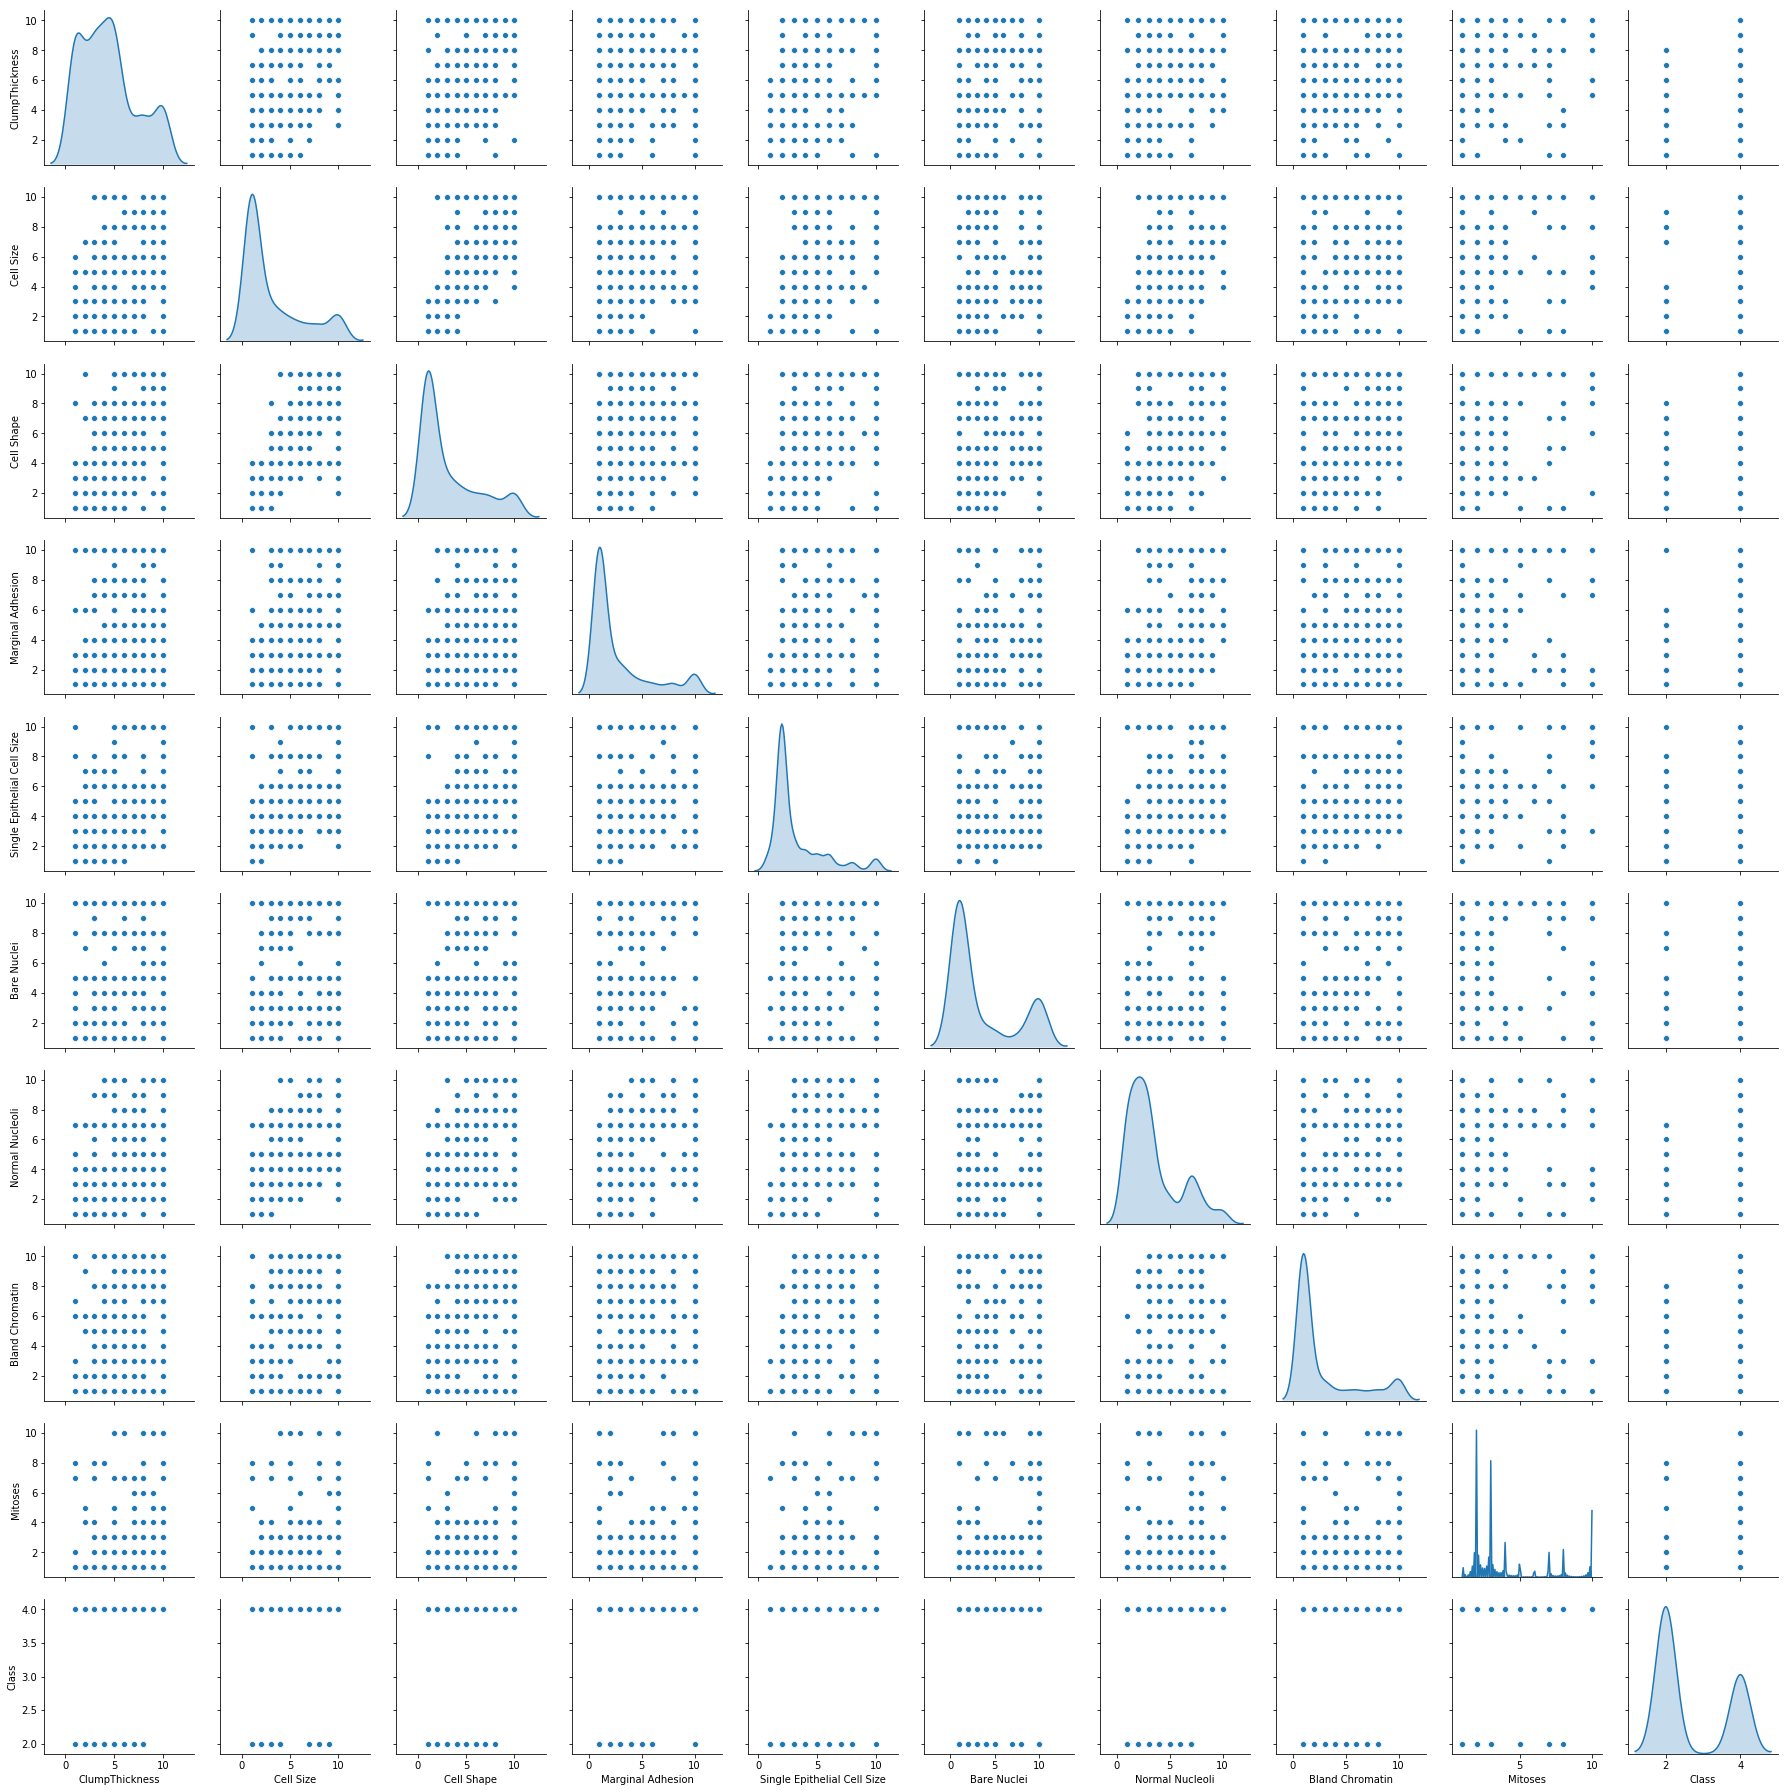

In [19]:
sns.pairplot(can_df, diag_kind='kde')

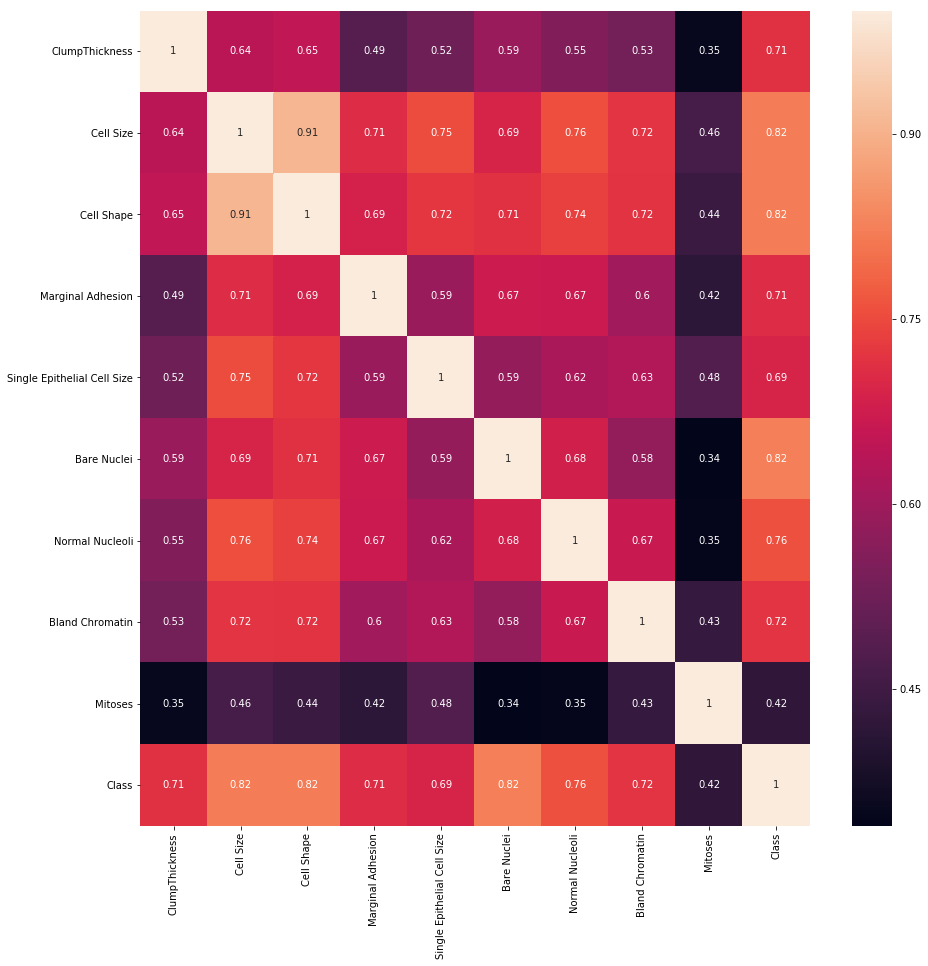

In [20]:
corr = can_df.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True)



# Q5 Remove any unwanted columns or outliers, standardize variables in this pre-processing step

In [21]:
# We could see most of the outliers are now removed.

In [22]:
pd.crosstab(can_df['Class'],can_df['Mitoses'])

Mitoses,1,2,3,4,5,6,7,8,10
Class,,,,,,,,,
2,431,8,2,0,1,0,1,1,0
4,132,27,31,12,5,3,8,7,14


In [23]:
can_df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,Class
0,5,1,1,1,2,1,3,1,1,2
1,5,4,4,5,7,10,3,2,1,2
2,3,1,1,1,2,2,3,1,1,2
3,6,8,8,1,3,4,3,7,1,2
4,4,1,1,3,2,1,3,1,1,2


In [24]:
X= can_df.drop('Class', axis=1)
Y=can_df['Class'] 
X.shape

(683, 9)

In [25]:
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)

/anaconda3/lib/python3.7/site-packages/sklearn/preprocessing/data.py:645: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.partial_fit(X, y)
/anaconda3/lib/python3.7/site-packages/sklearn/base.py:464: DataConversionWarning: Data with input dtype int64 were all converted to float64 by StandardScaler.
  return self.fit(X, **fit_params).transform(X)


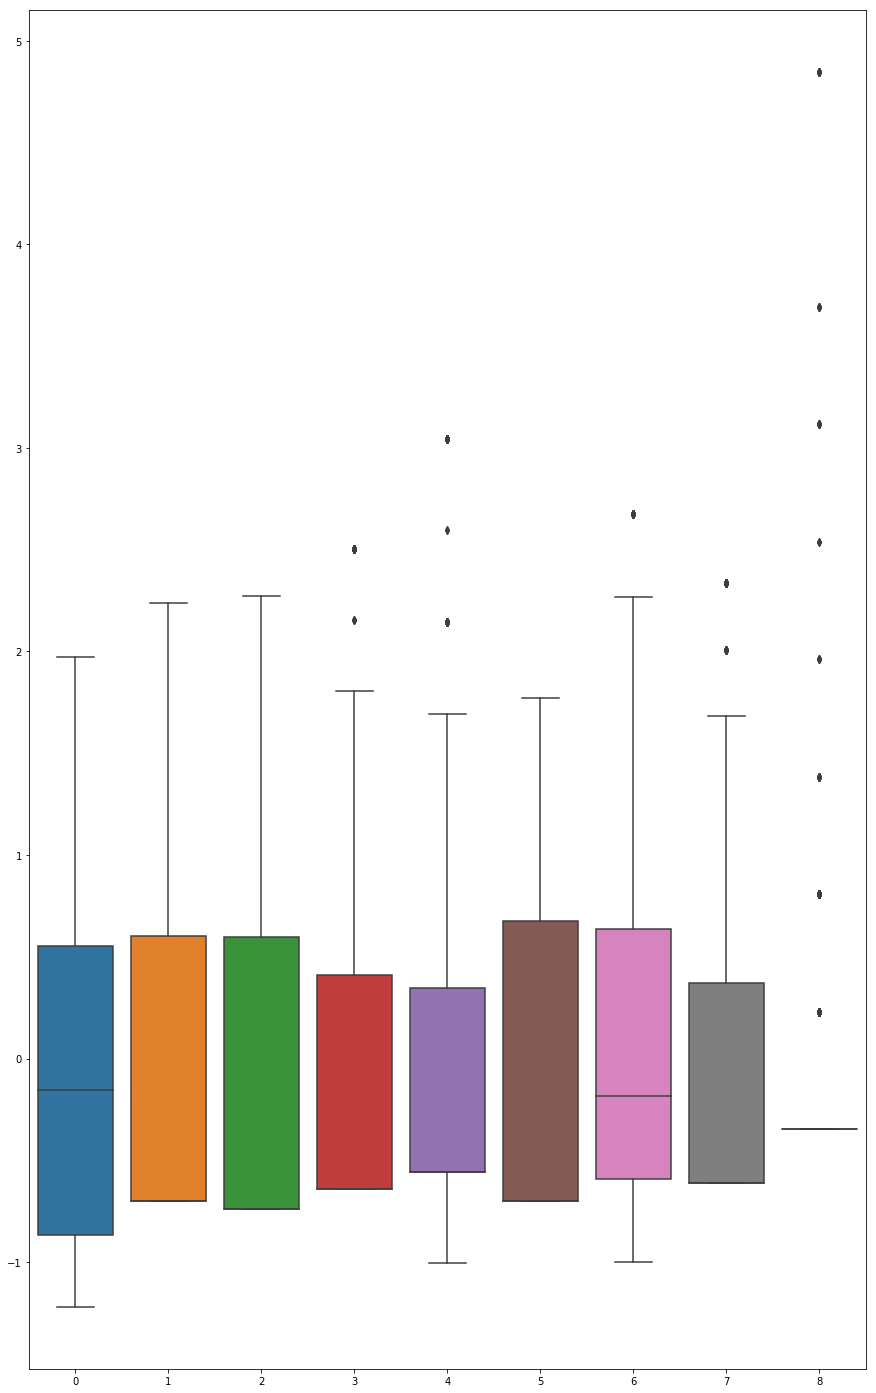

In [26]:
plt.figure(figsize=(15,25))
sns.boxplot(data=scaled_X )
plt.show()

# Q6 Create a covariance matrix for identifying Principal components

In [27]:
# PCA
# Step 1 - Create covariance matrix

In [28]:
cov_matrix = np.cov(scaled_X.T)

In [29]:
cov_matrix

array([[1.00146628, 0.64342355, 0.65442815, 0.48854401, 0.52436377,
        0.59396107, 0.55455439, 0.534849  , 0.35147177],
       [0.64342355, 1.00146628, 0.90855848, 0.70801357, 0.75464892,
        0.69272299, 0.75666702, 0.7204008 , 0.46143029],
       [0.65442815, 0.90855848, 1.00146628, 0.68695385, 0.72352174,
        0.71492429, 0.73642172, 0.71901615, 0.44190459],
       [0.48854401, 0.70801357, 0.68695385, 1.00146628, 0.59541954,
        0.67163165, 0.66954737, 0.6040054 , 0.41951256],
       [0.52436377, 0.75464892, 0.72352174, 0.59541954, 1.00146628,
        0.58657495, 0.61903424, 0.62984858, 0.48128796],
       [0.59396107, 0.69272299, 0.71492429, 0.67163165, 0.58657495,
        1.00146628, 0.68161283, 0.58513691, 0.33970781],
       [0.55455439, 0.75666702, 0.73642172, 0.66954737, 0.61903424,
        0.68161283, 1.00146628, 0.66657749, 0.34651824],
       [0.534849  , 0.7204008 , 0.71901615, 0.6040054 , 0.62984858,
        0.58513691, 0.66657749, 1.00146628, 0.43439328],


In [30]:
cov_matrix.shape

(9, 9)

# Q7 Identify eigen values and eigen vector

In [31]:
# Step 2- Get eigen values and eigen vector

In [32]:
eig_vals, eig_vecs = np.linalg.eig(cov_matrix)

In [33]:
print('Eigen Vectors \n%s', eig_vecs)
print('\n Eigen Values \n%s', eig_vals)

Eigen Vectors 
%s [[-3.02062573e-01 -1.40800531e-01  8.66372452e-01  2.74743825e-03
   1.07828438e-01  8.03212439e-02 -2.47707288e-01  2.42517517e-01
  -8.51566756e-03]
 [-3.80792973e-01 -4.66403106e-02 -1.99378011e-02  7.33210938e-01
  -2.04255399e-01 -1.45652870e-01  4.36299814e-01  1.39031681e-01
  -2.05434260e-01]
 [-3.77582540e-01 -8.24224677e-02  3.35108706e-02 -6.67480798e-01
  -1.75865604e-01 -1.08391546e-01  5.82726744e-01  7.45271259e-02
  -1.27209198e-01]
 [-3.32723572e-01 -5.20943760e-02 -4.12647341e-01 -4.60192106e-02
   4.93172568e-01 -1.95689775e-02 -1.63434032e-01  6.54628771e-01
   1.23830400e-01]
 [-3.36234038e-01  1.64404385e-01 -8.77425288e-02 -6.68906225e-02
  -4.27383577e-01 -6.36693247e-01 -4.58669096e-01 -6.93089143e-02
   2.11018210e-01]
 [-3.35067511e-01 -2.61260621e-01  6.91477953e-04  7.65102933e-02
   4.98617672e-01 -1.24772942e-01  1.26652879e-01 -6.09220540e-01
   4.02790095e-01]
 [-3.45747366e-01 -2.28076759e-01 -2.13071845e-01 -6.22410470e-02
   1.30473

# Q8 Find variance and cumulative variance by each eigen vector

In [34]:
eigen_pairs = [(np.abs(eig_vals[i]), eig_vecs[ :, i]) for i in range(len(eig_vals))]

In [35]:
tot = sum(eig_vals)
var_exp = [( i /tot ) * 100 for i in sorted(eig_vals, reverse=True)]
cum_var_exp = np.cumsum(var_exp)
print("Cumulative Variance Explained", cum_var_exp)

Cumulative Variance Explained [ 65.54999277  74.17162483  80.16331638  85.2702881   89.49557508
  92.84975787  96.12089914  99.01796423 100.        ]


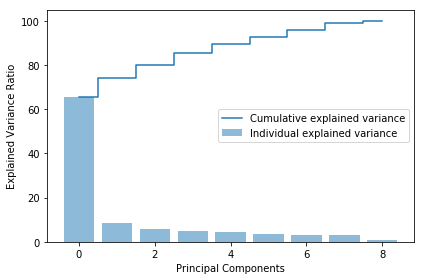

In [36]:
plt.figure(figsize=(6 , 4))
plt.bar(range(9), var_exp, alpha = 0.5, align = 'center', label = 'Individual explained variance')
plt.step(range(9), cum_var_exp, where='mid', label = 'Cumulative explained variance')
plt.ylabel('Explained Variance Ratio')
plt.xlabel('Principal Components')
plt.legend(loc = 'best')
plt.tight_layout()
plt.show()

# Q9 Use PCA command from sklearn and find Principal Components. Transform data to components formed

In [37]:
pca = PCA()
pca.fit(scaled_X)

PCA(copy=True, iterated_power='auto', n_components=None, random_state=None,
  svd_solver='auto', tol=0.0, whiten=False)

In [38]:
X_pca = pd.DataFrame(pca.transform(scaled_X),
                     columns=['PCA_0','PCA_1','PCA_2','PCA_3','PCA_4','PCA_5','PCA_6','PCA_7','PCA_8'])

In [39]:
X_pca.head()

,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8
0,-1.470171,-0.104273,-0.565685,-0.031959,-0.150998,0.060021,0.349403,0.420344,-0.005691
1,1.442046,-0.570141,0.236601,-0.478150,1.643085,-0.483035,-1.115899,0.379577,0.023427
2,-1.592478,-0.076120,0.048858,-0.092388,-0.059739,-0.279371,0.232740,0.209800,0.013372
3,1.479812,-0.528452,-0.603048,1.410827,-0.560737,0.063028,-0.211115,-1.607095,0.182777
4,-1.344862,-0.090719,0.029997,-0.338284,-0.108829,0.431370,0.259862,0.446655,-0.038820


In [40]:

X_pca.shape

(683, 9)

In [41]:
pca.components_

array([[ 3.02062573e-01,  3.80792973e-01,  3.77582540e-01,
         3.32723572e-01,  3.36234038e-01,  3.35067511e-01,
         3.45747366e-01,  3.35591377e-01,  2.30206398e-01],
       [-1.40800531e-01, -4.66403106e-02, -8.24224677e-02,
        -5.20943760e-02,  1.64404385e-01, -2.61260621e-01,
        -2.28076759e-01,  3.39658225e-02,  9.05557290e-01],
       [-8.66372452e-01,  1.99378011e-02, -3.35108706e-02,
         4.12647341e-01,  8.77425288e-02, -6.91477952e-04,
         2.13071845e-01,  1.34248356e-01, -8.04921698e-02],
       [-1.07828438e-01,  2.04255399e-01,  1.75865604e-01,
        -4.93172568e-01,  4.27383577e-01, -4.98617672e-01,
        -1.30473383e-02,  4.17113466e-01, -2.58987810e-01],
       [-8.03212439e-02,  1.45652870e-01,  1.08391546e-01,
         1.95689775e-02,  6.36693247e-01,  1.24772942e-01,
        -2.27665715e-01, -6.90210155e-01, -1.05041675e-01],
       [ 2.42517517e-01,  1.39031681e-01,  7.45271259e-02,
         6.54628771e-01, -6.93089143e-02, -6.092205

# Q10 Find correlation between components and features

##### Join Both PCA and original data frame to get correlation

In [42]:
merge_df=pd.concat([X,X_pca],axis=1)

In [43]:
merge_df.head()

,ClumpThickness,Cell Size,Cell Shape,Marginal Adhesion,Single Epithelial Cell Size,Bare Nuclei,Normal Nucleoli,Bland Chromatin,Mitoses,PCA_0,PCA_1,PCA_2,PCA_3,PCA_4,PCA_5,PCA_6,PCA_7,PCA_8
0,5.0,1.0,1.0,1.0,2.0,1.0,3.0,1.0,1.0,-1.470171,-0.104273,-0.565685,-0.031959,-0.150998,0.060021,0.349403,0.420344,-0.005691
1,5.0,4.0,4.0,5.0,7.0,10.0,3.0,2.0,1.0,1.442046,-0.570141,0.236601,-0.478150,1.643085,-0.483035,-1.115899,0.379577,0.023427
2,3.0,1.0,1.0,1.0,2.0,2.0,3.0,1.0,1.0,-1.592478,-0.076120,0.048858,-0.092388,-0.059739,-0.279371,0.232740,0.209800,0.013372
3,6.0,8.0,8.0,1.0,3.0,4.0,3.0,7.0,1.0,1.479812,-0.528452,-0.603048,1.410827,-0.560737,0.063028,-0.211115,-1.607095,0.182777
4,4.0,1.0,1.0,3.0,2.0,1.0,3.0,1.0,1.0,-1.344862,-0.090719,0.029997,-0.338284,-0.108829,0.431370,0.259862,0.446655,-0.038820


In [44]:
merge_df.shape

(699, 18)

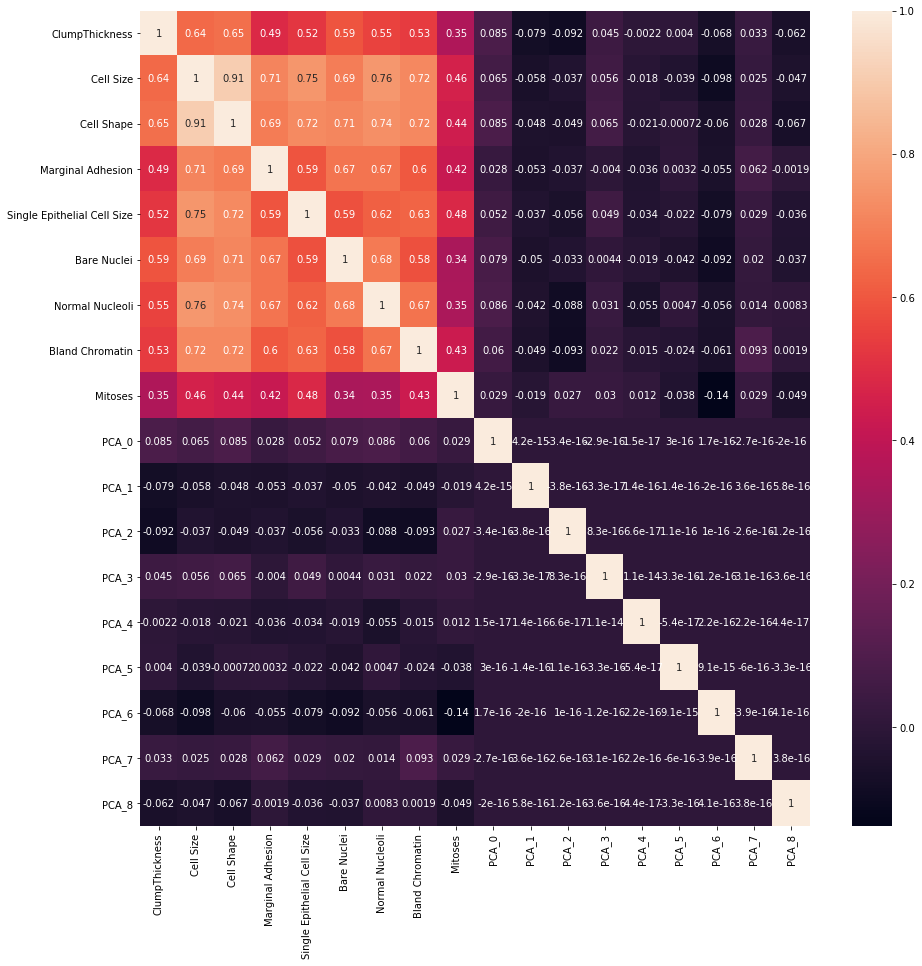

In [46]:
corr = merge_df.corr()

plt.figure(figsize=(15, 15))
sns.heatmap(corr, annot=True)